In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("questions.csv", encoding='latin1')

In [3]:
df = df.iloc[0:10000, :]
df.shape

(10000, 6)

In [4]:
df.shape

(10000, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            10000 non-null  int64
 1   qid1          10000 non-null  int64
 2   qid2          10000 non-null  int64
 3   question1     10000 non-null  str  
 4   question2     10000 non-null  str  
 5   is_duplicate  10000 non-null  int64
dtypes: int64(4), str(2)
memory usage: 1.6 MB


In [6]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [7]:
df.dropna(axis=0,inplace=True)


In [8]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["is_duplicate"].value_counts()

is_duplicate
0    6289
1    3711
Name: count, dtype: int64

<Axes: xlabel='is_duplicate'>

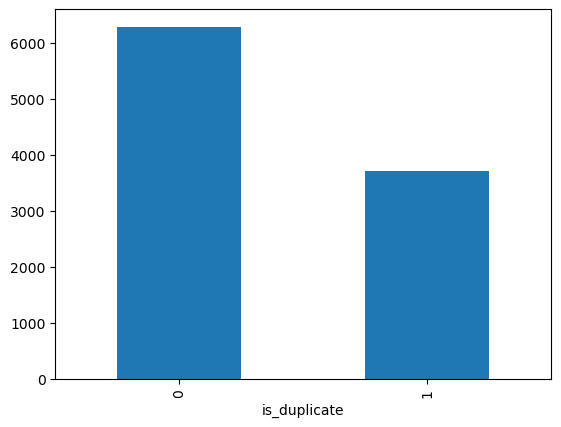

In [11]:
df["is_duplicate"].value_counts().plot(kind="bar")

In [12]:
df.drop(columns={"qid1","qid2"},inplace=True)

In [13]:
df.drop(columns={"id"},inplace=True)

In [14]:
df.head()

,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [15]:
from sklearn.feature_extraction.text import CountVectorizer

questions=list(df["question1"])+list(df["question2"])

cv=CountVectorizer(max_features=3000)
q1_array,q2_array=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [16]:
temp_df1=pd.DataFrame(q1_array,index=df.index)
temp_df2=pd.DataFrame(q2_array,index=df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape



(10000, 6000)

In [17]:
temp_df["is_duplicate"]=df["is_duplicate"]

In [18]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
x=temp_df.drop(columns={"is_duplicate"})
y=temp_df.iloc[:,-1]

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

x_train.shape,y_train.shape

((8000, 6000), (8000,))

In [20]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier()

rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,rfc.predict(x_test))

0.706

# Again Increasing accuracy 

In [21]:
new_df=df.copy()

In [22]:
new_df.head()

,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [23]:
new_df["q1_len"]=new_df["question1"].str.len()
new_df["q2_len"]=new_df["question2"].str.len()

In [24]:
new_df.head()

,question1,question2,is_duplicate,q1_len,q2_len
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39


In [27]:
new_df["q1_num_words"]=new_df["question1"].apply(lambda row: len(row.split(" ")))
new_df["q2_num_words"]=new_df["question2"].apply(lambda row: len(row.split(" ")))

In [28]:
new_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7


In [29]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [30]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,10
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,4
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,4
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,2


In [31]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [32]:
new_df['word_total'] = new_df.apply(total_words, axis=1)
new_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,10,23
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,4,20
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,4,24
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,0,19
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,2,20


In [33]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,10,23,0.43
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,4,20,0.20
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,4,24,0.17
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,0,19,0.00
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,2,20,0.10


<Axes: >

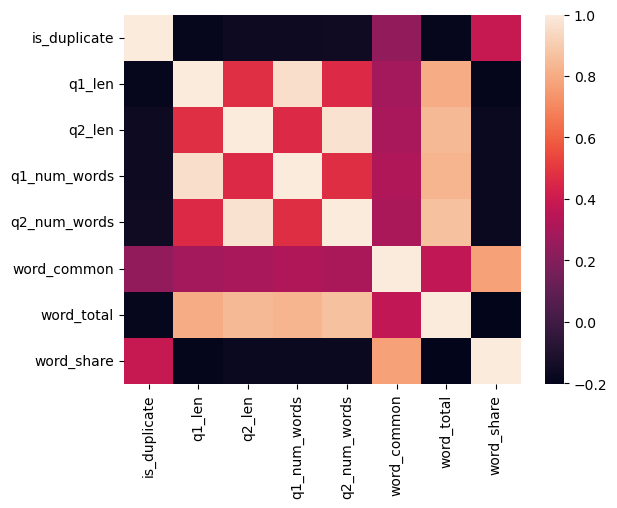

In [36]:
import seaborn as sns

sns.heatmap(new_df.corr(numeric_only=True))

In [37]:
ques_df=new_df[["question1","question2"]]
ques_df.head()

,question1,question2
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?


In [39]:
final_df=new_df.drop(columns=["question1","question2"])
final_df.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,0,66,57,14,12,10,23,0.43
1,0,51,88,8,13,4,20,0.20
2,0,73,59,14,10,4,24,0.17
3,0,50,65,11,9,0,19,0.00
4,0,76,39,13,7,2,20,0.10


In [40]:
from sklearn.feature_extraction.text import CountVectorizer

questions=list(ques_df["question1"])+list(ques_df["question2"])

cv=CountVectorizer(max_features=3000)

q1_array,q2_array=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [41]:
temp1=pd.DataFrame(q1_array,index=ques_df.index)
temp2=pd.DataFrame(q2_array,index=ques_df.index)

temp_df=pd.concat([temp1,temp2],axis=1)
temp_df.shape

(10000, 6000)

In [42]:
final_df=pd.concat([final_df,temp_df],axis=1)
final_df.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,0,66,57,14,12,10,23,0.43,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,51,88,8,13,4,20,0.20,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,73,59,14,10,4,24,0.17,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,50,65,11,9,0,19,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,76,39,13,7,2,20,0.10,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
x=final_df.drop(columns={"is_duplicate"})
y=pd.Series(final_df["is_duplicate"])

In [44]:
x.head()

,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,2,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,66,57,14,12,10,23,0.43,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,51,88,8,13,4,20,0.20,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,73,59,14,10,4,24,0.17,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,50,65,11,9,0,19,0.00,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,76,39,13,7,2,20,0.10,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    1
9999    0
Name: is_duplicate, Length: 10000, dtype: int64

In [47]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

x_train.shape,x_test.shape

((8000, 6007), (2000, 6007))

In [51]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier()

x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

rfc.fit(x_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,rfc.predict(x_test))

0.736

In [54]:
import pickle

In [55]:
pickle.dump(rfc, open('model.pkl', 'wb'))

In [59]:
model=pickle.load(open("model.pkl","rb"))

In [62]:
accuracy_score(y_test,model.predict(x_test))

0.736